In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Reading data base

### Database name:
* BC_database_final_version_final.db
### Database structure:
* **df1:** Breast_Cancer_Original
* **df2:** Breast_Cancer_Wisconsin
* **df3:** Breast_Cancer_Metabric
---


# Data Set 1:

## Breast Cancer Wisconsin (Categorical data)

- **Attributes**:
  
  1. Sample code number id number
  2. Clump Thickness 1 - 10
  3. Uniformity of Cell Size 1 - 10
  4. Uniformity of Cell Shape 1 - 10
  5. Marginal Adhesion 1 - 10
  6. Single Epithelial Cell Size 1 - 10
  7. Bare Nuclei 1 - 10
  8. Bland Chromatin 1 - 10
  9. Normal Nucleoli 1 - 10
  10. Mitoses 1 - 10
  11. Class (2 for benign, 4 for malignant)

**Original websites:**
1. https://www.kaggle.com/datasets/mariolisboa/breast-cancer-wisconsin-original-data-set
2. https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [8]:
import sqlite3
import pandas as pd
import os

# Build correct path
db_path = os.path.join("..", "data", "BC_database_final_version.db")

conn = sqlite3.connect(db_path)

df1 = pd.read_sql_query("SELECT * FROM Breast_Cancer_Original", conn)
conn.close()


# Heatmap visualization:

<Axes: >

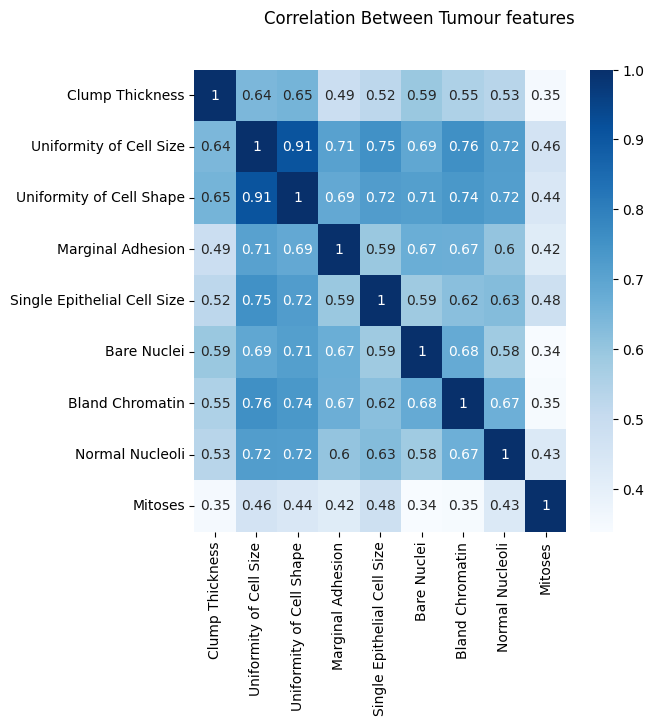

In [29]:
plt.figure(figsize=(6,6))
plt.suptitle("Correlation Between Tumour features")
sns.heatmap(df1.drop(columns=["Sample number","Class"]).corr(),annot=True,cmap="Blues")

# Clustermap visualization:

Visualizing in clusters the highest correlated features (Pearson values over 0.6)

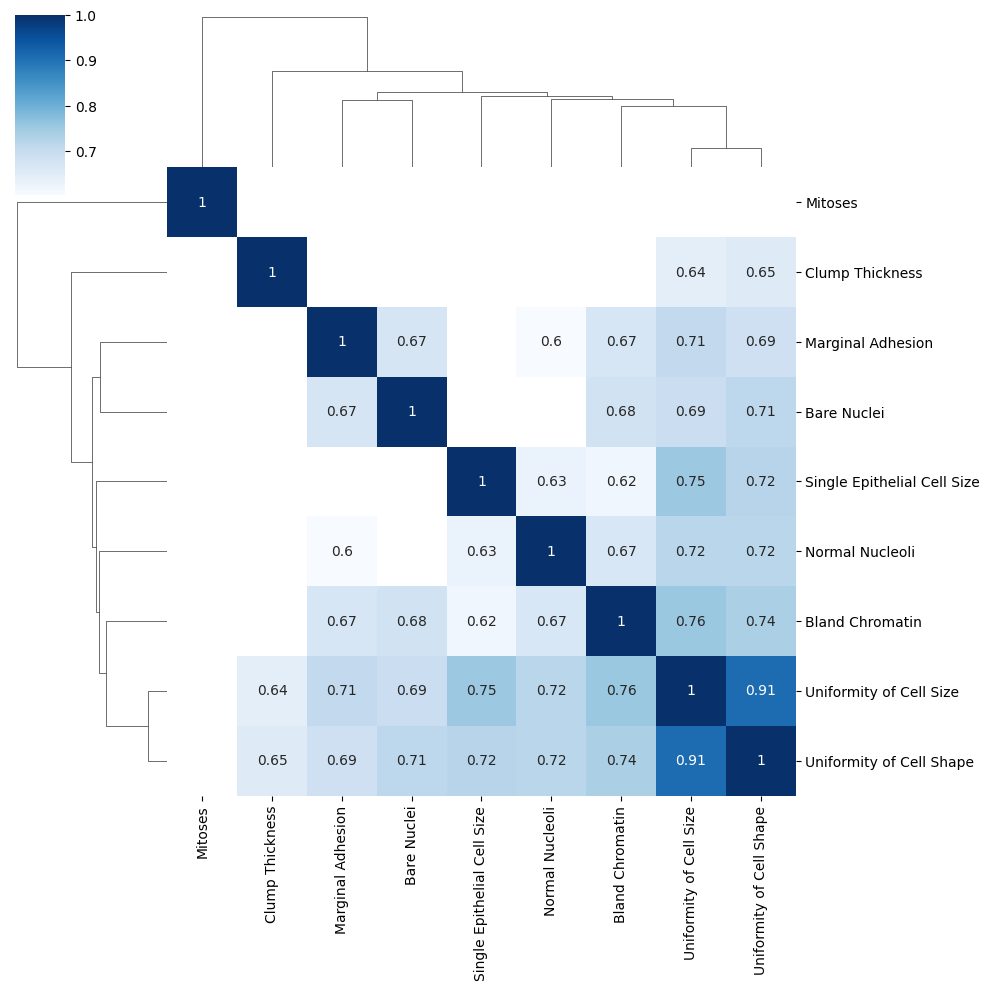

In [38]:
import numpy as np

corr = df1.drop(columns=["Sample number","Class"]).corr()

# Create mask for values <= 0.6
mask = np.abs(corr) < 0.6

sns.clustermap(
    corr,
    annot=True,
    cmap="Blues",
    mask=mask,
)

# Top 6 Highest pairwise Linear correlation:
* Uniformity of Cell Size, Uniformity of Cell Shape, Bland Chromatin, Normal Nucleoli, Single Epithelial Cell Size, Bare Nuclei

In [46]:
df1

,Sample number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1,5,1,1,1,2,1.0,3,1,1,Benign
1,2,5,4,4,5,7,10.0,3,2,1,Benign
2,3,3,1,1,1,2,2.0,3,1,1,Benign
3,4,6,8,8,1,3,4.0,3,7,1,Benign
4,5,4,1,1,3,2,1.0,3,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
678,679,3,1,1,1,3,2.0,1,1,1,Benign
679,680,2,1,1,1,2,1.0,1,1,1,Benign
680,681,5,10,10,3,7,3.0,8,10,2,Malignant
681,682,4,8,6,4,3,4.0,10,6,1,Malignant


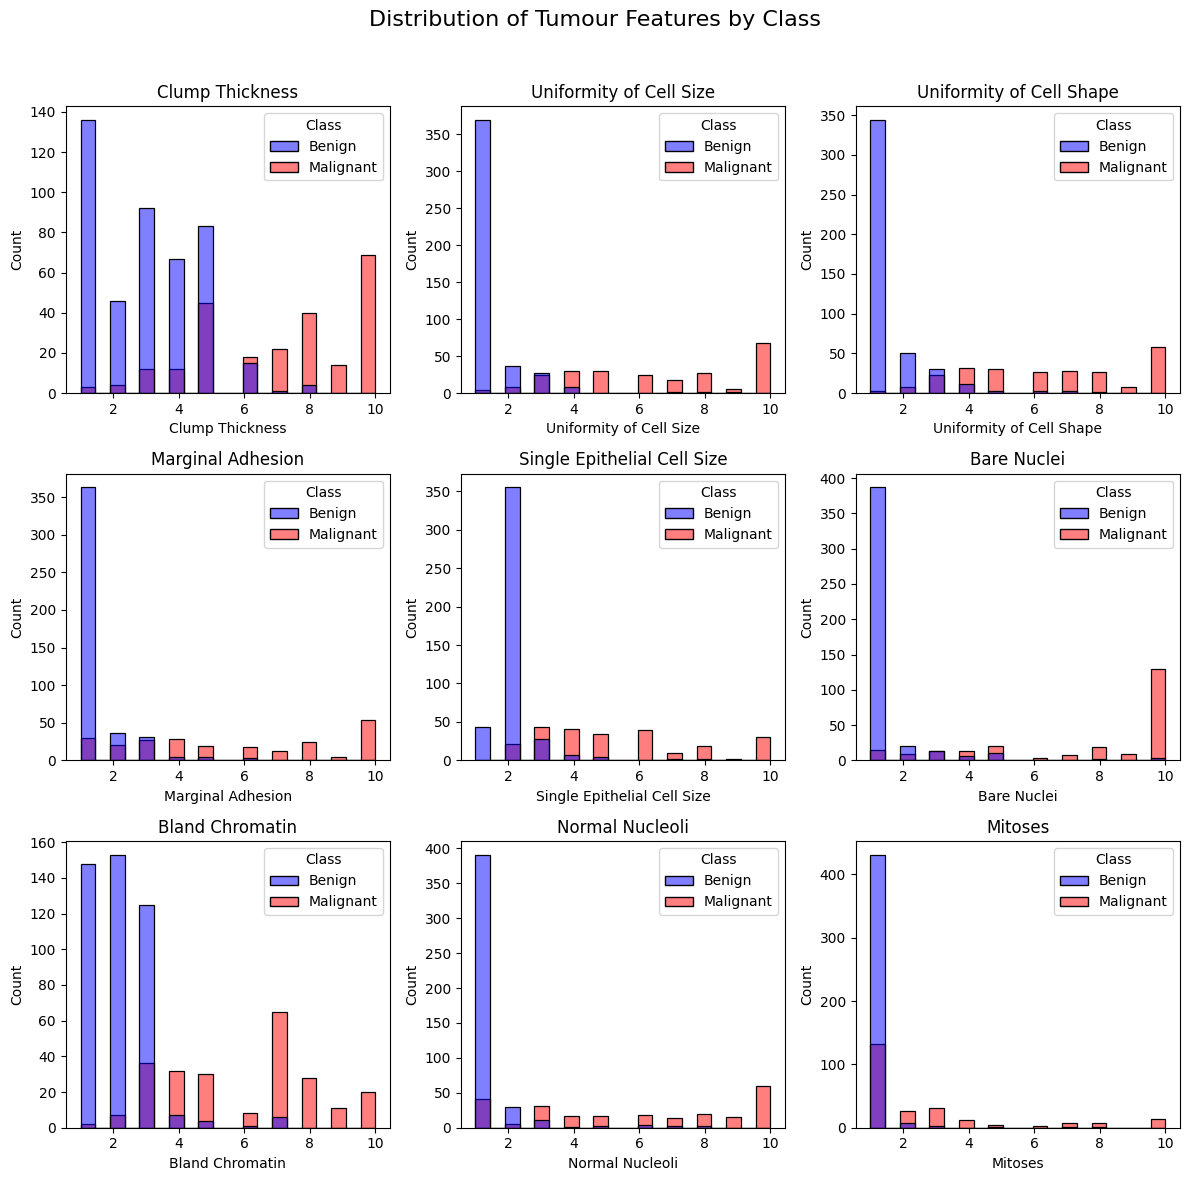

In [56]:
features = list(df1)[1:-1]

plt.figure(figsize=(12,12))

counter = 0
for i in features:
    counter += 1
    plt.subplot(3,3,counter)
    sns.histplot(
        df1,
        x=i,
        hue="Class",
        bins=20,
        palette={"Benign": "blue", "Malignant": "red"}  
    )
    plt.title(i)

plt.suptitle("Distribution of Tumour Features by Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  #
plt.show()

In [45]:
len(features)

9